**Example Python Code ❌ With Unclear Variable Names❌**

For the sake of illustration, here's some of our same word count Python code with poorly named variables. The code works exactly the same as our original code, but it's a lot harder to read.

In [ ]:
import re
def sp(t):
    lt = t.lower()
    sw = re.split(r"\W+", lt)
    return sw

f = "./datasets/Texts/The-Yellow-Wallpaper_Charlotte-Perkins-Gilman.txt"
ft = open(f, encoding="utf-8").read()

words = sp(ft)
len(words)

**Example Python Code ✨ With Clearer Variable Names ✨**

In [ ]:
def split_into_words(any_chunk_of_text):
    lowercase_text = any_chunk_of_text.lower()
    split_words = re.split(r"\W+", lowercase_text)
    return split_words

filepath_of_text = "./datasets/Texts/The-Yellow-Wallpaper_Charlotte-Perkins-Gilman.txt"
full_text = open(filepath_of_text, encoding="utf-8").read()

all_the_words = split_into_words(full_text)
len(all_the_words)

---

### Overview: Application-specific cleaning workflow

#### Purpose

In this notebook, I'm going to construct three  graphs as follows:
1. I construct a bipartite graph `B` from the dataframe prepared above, where `B` comprises two node sets, namely the _actor name_ node set and _movie title_ node set. I call this graph the _**movie-actor graph**_.
1. I apply projection onto the actor nodes to create the graph `C` from the bipartite graph, which I call the _**co-actor graph**_.
1. I apply projection onto the title nodes to create the graph `S` from the bipartite graph, which I call the _**shared-actor graph**_.

![](img/three%20graphs.png)

---

#### Overview

1. Remove unnecessary rows: TV shows
2. Check whether `show_ids` are unique.
3. Check whether `titles` are unique.
4. Calculate the set of nodes `actor_names`: Tokenize the `cast` field.
5. Check whether there is an intersection between `movie_titles` and `actor_names`.
6. Some statistics: average number of `actors` per `movie` etc.

---

#### Remove unnecessary rows: TV shows

In [ ]:
# Importing Libraries and Loading Data
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import networkx as nx

In [ ]:
# Load dataset
df_clean = pd.read_pickle('./datasets/Netflix Streaming Data/Netflix Streaming Data-Cleaned.pkl')
print(df_clean.info())
df_clean.head()

In [ ]:
# Consider only rows of type = "Movie".
df_movie = df_clean[df_clean['type'] == 'Movie']
df_movie = df_movie.reset_index(drop=True)
df_movie.info()

---

#### Unique identifiers for movies

For the moment, we have 5656 movies. For constructing the bipartite graph, we need unique identifiers for movies.

In [ ]:
print(len(set(df_movie["show_id"])))
print(len(df_movie["show_id"].unique()))

---

#### Check whether `title` entries are unique.

In [ ]:
print(len(set(df_movie["title"].str.strip())))
print(len(df_movie["title"].unique()))

---

#### Create a set of `actor_names` from the `cast` entries.

In [ ]:
movie_titles = set(df_movie["title"].str.strip())
actor_names  = set()

for idx, row in df_movie.iterrows():
    actor_names.update([actor.strip() for actor in row['cast'].split(',')])

print(f"Total number of movie titles: {len(movie_titles)}")
print(f"Total number of actor names: {len(actor_names)}")

---

#### Check whether there is an intersection between `movie_titles` and `actor_names`.

In [ ]:
intersect = movie_titles.intersection(actor_names)
print(f"Movie titles that are also actor names: {intersect}")

As the intersection between the `movie_titles` set and the `actor_names` set is not null, we have to use the `show_ids` set to construct the bipartite graph. 

count    5633.000000
mean        7.862773
std         3.899367
min         1.000000
25%         6.000000
50%         8.000000
75%        10.000000
max        44.000000
Name: cast, dtype: float64


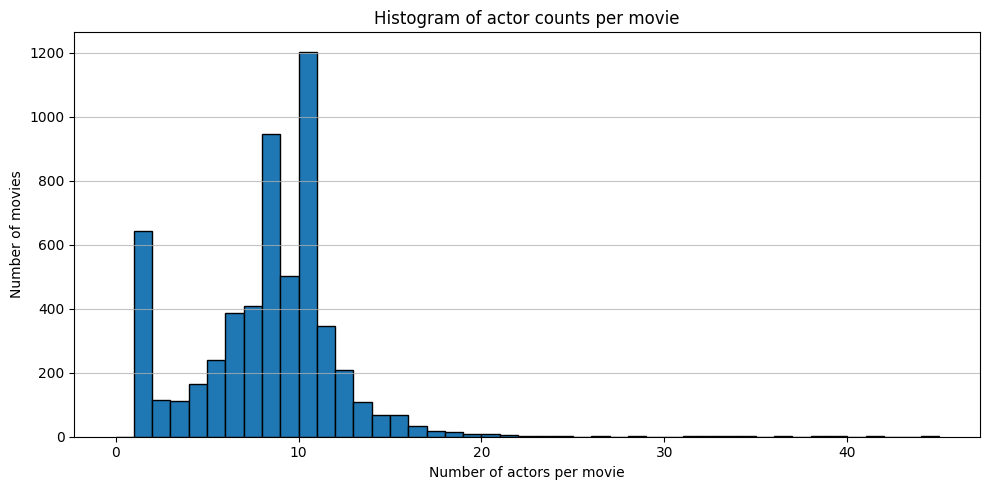

cast
1      642
2      114
3      113
4      166
5      240
6      387
7      409
8      945
9      503
10    1204
11     347
12     210
13     108
14      68
15      68
16      33
17      18
18      15
19       8
20       9
Name: count, dtype: int64


In [ ]:
# AI-generated content: This code computes the number of actors per movie, provides summary statistics, 
# and visualizes the distribution of actor counts per movie using a histogram. 
# It also prints the distribution of actor counts for the first 20 counts. 
# The prompt was: "compute a histogram for the number of actors per movie."

# Compute the number of actors per movie (split cast by comma and strip whitespace)
actors_per_movie = df_movie['cast'].fillna('').apply(
    lambda s: len([a for a in (x.strip() for x in s.split(',')) if a])
)

# Summary statistics
print(actors_per_movie.describe())

# Plot histogram
plt.figure(figsize=(10, 5))
plt.hist(actors_per_movie, bins=range(0, actors_per_movie.max() + 2), edgecolor='black')
plt.xlabel('Number of actors per movie')
plt.ylabel('Number of movies')
plt.title('Histogram of actor counts per movie')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

# Print distribution of actor counts
actor_count_dist = actors_per_movie.value_counts().sort_index()
print(actor_count_dist.head(20))